# Problem set 1: example workflow

Import necessary modules:

In [1]:
import numpy as np
import pandas as pd
from scipy.linalg import lstsq
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import ridge_regression
import matplotlib.pyplot as plt
import seaborn as sns

## Question 1

*Reproduce the figure for Q3 in the Pre-course Quiz. ([Figure Link](https://drive.google.com/file/d/15WejYTcSHDGM3VNoX32WaD5r8l-BNNF-/view?usp=sharing)) Figure credit: Nicolas P. Rougier (2021).*

Here's sample code to reproduce the figure:

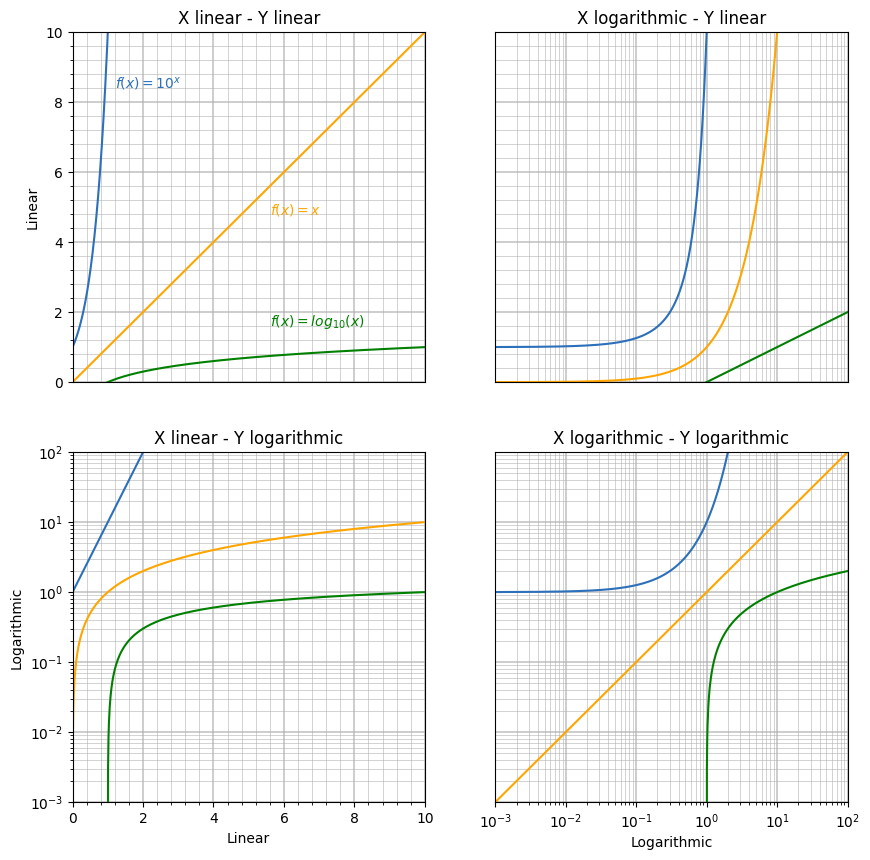

In [2]:
# Create figure with (2x2) panels
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# flatten axs so the (2x2) panels can be accessed by axsf[0] to axsf[3] 
axsf = axs.flatten()

# Define sample locations from 0.001 (10^-3) to 100 (10^2)
x = np.logspace(-3, 2, 1000)

# Plot three lines and set the grid properties for each panel
for ax in axsf:
    ax.plot(x, 10 ** x,     color='xkcd:medium blue')
    ax.plot(x, x,           color='orange'          )
    ax.plot(x, np.log10(x), color='green'           )
    ax.grid(True, which='major', alpha=0.8, linewidth=1.1)
    ax.grid(True, which='minor', alpha=0.8, linewidth=0.5)

# Settings for Plot 1: X linear - Y linear
axsf[0].set_xlim(0, 10)
axsf[0].set_ylim(0, 10)
axsf[0].set_title('X linear - Y linear')
axsf[0].xaxis.set_major_locator(plt.MultipleLocator(2))   # Major gridlines every 2 units
axsf[0].xaxis.set_minor_locator(plt.MultipleLocator(0.4)) # Minor gridlines every 0.4 units
axsf[0].yaxis.set_major_locator(plt.MultipleLocator(2))  
axsf[0].yaxis.set_minor_locator(plt.MultipleLocator(0.4))
axsf[0].tick_params(axis='x', which='both', length=0)     # Disable ticks
axsf[0].set_xticklabels([])                               # Disable tick labels
axsf[0].set_ylabel('Linear')
axsf[0].text(1.2, 8.4, r'$f(x) = 10^x$', color='xkcd:medium blue')
axsf[0].text(5.6, 4.8, r'$f(x) = x$', color='orange')
axsf[0].text(5.6, 1.6, r'$f(x) = log_{10}(x)$', color='green')

# Settings for Plot 2: X logarithmic - Y linear
axsf[1].set_xscale('log')
axsf[1].set_xlim(1e-3, 1e2)
axsf[1].set_ylim(0, 10)
axsf[1].set_title('X logarithmic - Y linear')
axsf[1].yaxis.set_major_locator(plt.MultipleLocator(2))  
axsf[1].yaxis.set_minor_locator(plt.MultipleLocator(0.4)) 
axsf[1].tick_params(axis='both', which='both', length=0)
axsf[1].set_xticklabels([])
axsf[1].set_yticklabels([])

# Settings for Plot 3: X linear - Y logarithmic
axsf[2].set_yscale('log')
axsf[2].set_xlim(0, 10)
axsf[2].set_ylim(1e-3, 1e2)
axsf[2].set_title('X linear - Y logarithmic')
axsf[2].xaxis.set_major_locator(plt.MultipleLocator(2)) 
axsf[2].xaxis.set_minor_locator(plt.MultipleLocator(0.4)) 
axsf[2].set_xlabel('Linear')
axsf[2].set_ylabel('Logarithmic')

# Settings for Plot 4: X logarithmic - Y logarithmic
axsf[3].set_xscale('log')
axsf[3].set_yscale('log')
axsf[3].set_xlim(1e-3, 1e2)
axsf[3].set_ylim(1e-3, 1e2)
axsf[3].set_title('X logarithmic - Y logarithmic')
axsf[3].tick_params(axis='y', which='both', length=0)
axsf[3].set_xlabel('Logarithmic')
axsf[3].set_yticklabels([]);

## Exercise 5.7

Load `Milwaukee_wind_direction_ozone.csv` and set x = `wind_direction` and y = `ozone`:

In [3]:
milwaukee = pd.read_csv('Milwaukee_wind_direction_ozone.csv')
x = milwaukee['wind_direction'].to_numpy()
y = milwaukee['ozone'].to_numpy()

Next, we build the architecture of a linear model $\textbf{y} = \textbf{X}\textbf{a}$. Since we want to model the intercept, the first column of $\textbf{X}$ should be $\textbf{1}$, and then the intercept parameter will be the first element of $\textbf{a}$. We set up the required predictor conditions (i.e., $\textbf{X}$) for each model in (a) and (b), so eight models in total:

In [4]:
x_shift = (x + 60) % 360      # e.g. Azimuth 370 deg = 10 deg
ones = np.ones_like(x)        # to be added as the first column of X for modeling intercept
coss = np.cos(np.deg2rad(x))
sins = np.sin(np.deg2rad(x))
coss_shift = np.cos(np.deg2rad(x_shift))
sins_shift = np.sin(np.deg2rad(x_shift))
model_Xs = {}
labels =     ['a-i', 'a-ii',       'a-iii', 'a-iv', 'b-i',     'b-ii',                   'b-iii',      'b-iv']
predictors = [[x],   [coss, sins], [coss],  [sins], [x_shift], [coss_shift, sins_shift], [coss_shift], [sins_shift]]
for label, predictor in zip(labels, predictors):
    predictor_addones = [ones] + predictor
    model_Xs[label]   = np.stack(predictor_addones, axis=-1)

Now we use `scipy.linalg.lstsq` to solve the model with the following loss function (i.e., ordinary least square; OLS):

$J = ||\textbf{y} - \textbf{X}\textbf{a}||_2^2$

In [5]:
for key, X in model_Xs.items():
    a, res, _, _ = lstsq(X, y)
    rmse = np.sqrt(res / y.size)
    if len(a) == 2:
        print(f'({key:5s}) Optimized OLS model: y = {a[0]:6.2f} + {a[1]:6.2f}x,            RMSE = {rmse:.2f}')
    elif len(a) == 3:
        print(f'({key:5s}) Optimized OLS model: y = {a[0]:6.2f} + {a[1]:6.2f}x1 + {a[2]:5.2f}x2, RMSE = {rmse:.2f}')

(a-i  ) Optimized OLS model: y =  73.28 +  -0.16x,            RMSE = 20.40
(a-ii ) Optimized OLS model: y =  41.24 +  11.32x1 + 29.27x2, RMSE = 19.77
(a-iii) Optimized OLS model: y =  46.60 +   9.29x,            RMSE = 28.19
(a-iv ) Optimized OLS model: y =  46.91 +  28.84x,            RMSE = 20.59
(b-i  ) Optimized OLS model: y =  57.23 +  -0.05x,            RMSE = 28.22
(b-ii ) Optimized OLS model: y =  41.24 + -19.69x1 + 24.44x2, RMSE = 19.77
(b-iii) Optimized OLS model: y =  54.10 + -24.38x,            RMSE = 23.64
(b-iv ) Optimized OLS model: y =  36.12 +  29.97x,            RMSE = 23.46


A good model should give the same results regardless of the added azimuth. The direct use of `x` as a predictor is not good since (a-i) and (b-i) have large differences in RMSE. Using only $\sin x$ or $\cos x$ is not optimal either. Since they do not sufficiently model the circular behavior, the model parameters and RMS change with an added angular shift. The only working model is 

$y = a_0 + a_1\cos \frac{2 \pi \theta}{360} +a_2 \sin \frac{2 \pi \theta}{360} + \epsilon$,

as seen from the same RMSE of (a-ii) and (b-ii).

## Exercise 5.8

It is always important to visualize and explore the data before a formal analysis. For `SWE_tele.csv`, I've created an [interactive plot](https://claude.site/artifacts/91ff72d4-6b52-43f9-8637-12426f4434c8) using Claude.ai for you to take a look!

Load `SWE_tele.csv` and perform the following steps:
- Assign $\textbf{y}$ (SWE)
- Prepare $\textbf{X}$ by adding a column of 1's
- Train-validation data split

In [6]:
swe = pd.read_csv('SWE_tele.csv')

y = swe.iloc[:, 1].to_numpy()    # SWE
X_no_intercept = swe.iloc[:, 2:].to_numpy()    # four predictors: Nino34, PNA, NAO, & AO
X = np.c_[np.ones_like(y), X_no_intercept]    # Add one column of 1's to X for modeling intercept 

X_train, X_vali, y_train, y_vali = train_test_split(X, y, train_size=45, shuffle=False)

For this question, our model can be characterized as follows:

- Architecture: $y = a_0 + \sum_{i=1}^m a_ix_i + \epsilon$
- Loss function: $J = ||\textbf{y} - \textbf{X}\textbf{a}||_2^2$

where $m$ is the number of predictors. We use the statsmodels package to solve for the model parameters and the p-value for each predictor. Each p-value is associated with a two-tailed t-test and a null hypothesis that the corresponding model parameter is zero.

Let's define a function for this regression workflow. it also prints the RMSE of training/validation data as well as all p-values.

In [7]:
def ols_ex58(X_train, X_vali, y_train, y_vali):
    model = sm.OLS(y_train, X_train)
    results = model.fit()

    a = results.params        # model parameters; a[0] is intercept
    pval = results.pvalues

    rmse_train = mean_squared_error(y_train, X_train @ a, squared=False)
    rmse_vali  = mean_squared_error(y_vali,  X_vali  @ a, squared=False)
    
    print(f'    RMSE of training data:   {rmse_train:.2f}\n    RMSE of validation data: {rmse_vali:.2f}')
    print(f'    p-values of the two-tailed t tests:')
    for i in range(len(pval)):
        print(f'      a{i}: {pval[i]:.3e}')

We start with the full model where all predictors are retained:

In [8]:
print(f'(a) Model: y = a0 + a1 * Nino34 + a2 * PNA + a3 * NAO + a4 * AO')
ols_ex58(X_train, X_vali, y_train, y_vali)

(a) Model: y = a0 + a1 * Nino34 + a2 * PNA + a3 * NAO + a4 * AO
    RMSE of training data:   424.74
    RMSE of validation data: 544.18
    p-values of the two-tailed t tests:
      a0: 3.581e-20
      a1: 2.470e-01
      a2: 2.095e-02
      a3: 2.365e-01
      a4: 2.860e-01


Next, we remove `AO` from $\textbf{X}$ since it has the largest p value among the predictors. Perform the workflow again:

In [9]:
X_train_crop1 = X_train[:, [0, 1, 2, 3]]
X_vali_crop1 = X_vali[:, [0, 1, 2, 3]]

print(f'(b) Model: y = a0 + a1 * Nino34 + a2 * PNA + a3 * NAO')
ols_ex58(X_train_crop1, X_vali_crop1, y_train, y_vali)

(b) Model: y = a0 + a1 * Nino34 + a2 * PNA + a3 * NAO
    RMSE of training data:   430.90
    RMSE of validation data: 552.96
    p-values of the two-tailed t tests:
      a0: 6.041e-22
      a1: 2.503e-01
      a2: 7.388e-03
      a3: 5.707e-01


Next, we remove `PNA` from $\textbf{X}$ since it has the largest p value among the predictors. Perform the workflow again:

In [10]:
X_train_crop2 = X_train[:, [0, 1, 2]]
X_vali_crop2 = X_vali[:, [0, 1, 2]]

print(f'(c) Model: y = a0 + a1 * Nino34 + a2 * PNA')
ols_ex58(X_train_crop2, X_vali_crop2, y_train, y_vali)

(c) Model: y = a0 + a1 * Nino34 + a2 * PNA
    RMSE of training data:   432.62
    RMSE of validation data: 541.90
    p-values of the two-tailed t tests:
      a0: 2.106e-22
      a1: 2.621e-01
      a2: 5.578e-03


Next, we remove `Nino34` from $\textbf{X}$ since it has the largest p value among the predictors. Perform the workflow again:

In [11]:
X_train_crop3 = X_train[:, [0, 2]]
X_vali_crop3 = X_vali[:, [0, 2]]

print(f'(d) Model: y = a0 + a1 * PNA')
ols_ex58(X_train_crop3, X_vali_crop3, y_train, y_vali)

(d) Model: y = a0 + a1 * PNA
    RMSE of training data:   439.22
    RMSE of validation data: 578.30
    p-values of the two-tailed t tests:
      a0: 1.198e-22
      a1: 7.031e-04


We can see that if we only look at the p-values calculated from the training data, we will likely arrive at model (d) since it is the only model where all predictors are significant (at $p < 0.05$ level). However, the RMSE of validation data is the lowest for (c), indicating a potentially better model in the sense of generalization.

## Exercise 5.9

Load `SWE_tele.csv` and perform the following steps:

- Keep only the necessary predictors as requested by the question.
- **Scale the data** since we will be using a regularized model.
- Assign $\textbf{y}$ (SWE)

In [12]:
swe = pd.read_csv('SWE_tele.csv')
swe_used = swe.iloc[:, 1:4]    # only SWE (y), Nino34 (x1), PNA (x2) are used

# Scale the data
scaler = StandardScaler()
scaler.fit(swe_used)
swe_scaled = scaler.transform(swe_used)

# assign y
y = swe_scaled[:, 0]

Now, perform all the necessary regression runs and collect the results using a nested loop. Our ridge regression models can be characterized as follows:

- Architecture: $y = a_0 + \sum_{i=1}^m a_ix_i + \epsilon$
- Loss function: $J = ||\textbf{y} - \textbf{X}\textbf{a}||_2^2 + \alpha||\textbf{a}||_2^2$

where $\alpha$ is the regularization parameter. It is equivalent to $\lambda$ in the textbook and in the question. We use $\alpha$ in the code simply to follow the naming convention of scikit-learn.

Note that:

- We add a column of 1's using `sm.add_constant` this time. In fact, there are also ways to run the regression models without explicitly adding a constant. See my comment in the code for details.
- We use `sklearn.linear_model.ridge_regression` to solve the parameters in a ridge regression model. However, if $\alpha = 0$, we use `scipy.linalg.lstsq` instead since the former may be buggy.

In [13]:
aggregated_results = []
alpha_list = [0, 1e-5, 1e-2]    # The first one is just the OLS.

for alpha in alpha_list:
    coeff_collection = []

    # 100 runs for each alpha value
    for i in range(100):    
        # Make up x3 and design the X
        x3 = swe_scaled[:, -1] + 0.001 * np.random.randn(swe_scaled.shape[0])
        x123 = np.hstack((swe_scaled[:, 1:], x3.reshape(-1, 1)))
        X = sm.add_constant(x123)
        ######## Note: there are also ways to run the regression models without explicitly adding a constant. ####
        ######## For example, you can set up the return_intercept flag of the ridge_regression funtion:
        # coef, intercept = ridge_regression(x123, y, alpha=alpha, return_intercept=True)
        ######## Alternatively, you can use the Ridge instance to perform the ridge regression:
        # from sklearn.linear_model import Ridge
        # clf = Ridge(alpha=alpha)
        # clf.fit(x123, y)
        # coef = clf.coef_
        # intercept = clf.intercept_
        ##########################################################################################################
        
        # Split the training and validation sets as instructed
        X_train, X_vali, y_train, y_vali = train_test_split(X, y, train_size=45, shuffle=False)
    
        # Perform regression
        if alpha == 0:
            # Use lstsq when alpha = 0
            coef, _, _, _   = lstsq(X_train, y_train)
        else:
            coef = ridge_regression(X_train, y_train, alpha=alpha)

        # Calculate RMSE for both training and validation data sets
        rmse_train = mean_squared_error(y_train, X_train @ coef, squared=False)
        rmse_vali  = mean_squared_error(y_vali,  X_vali  @ coef, squared=False)
        ######## Note: if you use scikit-learn >= 1.4, there will be root_mean_squared_error for use: ####
        # from sklearn.metrics import root_mean_squared_error
        # rmse_train = root_mean_squared_error(y_train, X_train @ coef)
        # rmse_vali  = root_mean_squared_error(y_vali,  X_vali  @ coef)
        ##################################################################################################

        # Tie up the values to be sent to the parent loop
        coeff_onerun = np.concatenate((coef, [rmse_train, rmse_vali]))
        coeff_collection.append(coeff_onerun)

    # Calculate mean & std for everything
    coeff_collection = np.array(coeff_collection)
    model_mean = np.mean(coeff_collection, axis=0)
    model_std = np.std(coeff_collection, axis=0)
    model_results = np.concatenate(([alpha], model_mean, model_std))
    aggregated_results.append(model_results)

# Convert the results to pandas DataFrame for a beautiful layout
aggregated_results_df = pd.DataFrame(aggregated_results, columns=
                                     ['alpha', 'mean_a0', 'mean_a1', 'mean_a2', 'mean_a3', 'mean_rmse_train', 'mean_rmse_vali', 
                                      'std_a0', 'std_a1', 'std_a2', 'std_a3', 'std_rmse_train', 'std_rmse_vali'])

In [14]:
aggregated_results_df

,alpha,mean_a0,mean_a1,mean_a2,mean_a3,mean_rmse_train,mean_rmse_vali,std_a0,std_a1,std_a2,std_a3,std_rmse_train,std_rmse_vali
0,0.00000,-0.151376,-0.168771,-25.248308,24.868313,0.816778,1.047763,0.019069,0.022586,142.814856,142.810266,0.013471,0.036763
1,0.00001,-0.149935,-0.169884,2.532126,-2.911119,0.818491,1.040416,0.013873,0.017456,95.130303,95.127530,0.012595,0.019713
2,0.01000,-0.150745,-0.169511,-0.161414,-0.216978,0.828425,1.037756,0.000050,0.000078,0.290551,0.290612,0.000081,0.000082
